# Mobile Money Fraud Detection

## AI Engineering Challenge - Phase 1: Data Science

**Candidate Name:** [Mercy Mawua Musyoka]  
**Date:** [24/03/2026]

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
   - 2.1 Basic Statistics
   - 2.2 Target Variable Analysis
   - 2.3 Temporal Analysis
   - 2.4 Transaction Type Analysis
   - 2.5 Amount Analysis
   - 2.6 Geographic Analysis
   - 2.7 User Behavior Analysis
3. [Feature Engineering](#3-feature-engineering)
   - 3.1 Temporal Features
   - 3.2 Transaction Velocity Features
   - 3.3 Amount-Based Features
   - 3.4 Behavioral Features
   - 3.5 Device & Location Features
4. [Data Preprocessing](#4-data-preprocessing)
5. [Model Development](#5-model-development)
   - 5.1 Baseline Model
   - 5.2 Model Comparison
   - 5.3 Hyperparameter Tuning
   - 5.4 Final Model Evaluation
6. [Model Interpretation](#6-model-interpretation)
7. [Conclusions & Next Steps](#7-conclusions--next-steps)
8. [Test Set Predictions](#8-test-set-predictions) ⭐ REQUIRED

---

## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set display options
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
# making notebook reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load the data
# TODO: Load the transactions dataset
df = pd.read_csv(r"../data/transactions.csv")

# Preview data
df.head()


,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,device_id,location_lat,location_lon,is_fraud
0,6EB4D46BA1B3D436,2024-01-01 00:24:12,USR000197,USR006604,701.74,send_money,93725.40,93023.66,155223.20,155924.94,DEV00009299,-0.479970,39.534387,0
1,B6483765E2F120B3,2024-01-01 01:21:24,USR003827,USR001772,262.18,pay_bill,168781.46,168519.28,71813.67,72075.85,DEV00007045,-1.025984,37.128477,0
2,1FFF0622A1441845,2024-01-01 01:33:17,USR007516,USR004366,446.42,send_money,140544.59,140098.17,40409.07,40855.49,DEV00007637,-0.570625,34.854586,0
3,4EE0C335368E4144,2024-01-01 01:53:47,USR002133,USR002447,69999.00,pay_bill,162797.10,92798.10,124725.77,194724.77,DEV00010447,4.514332,32.957873,1
4,D769B217438B8593,2024-01-01 02:03:26,USR001867,USR007013,75000.00,send_money,122467.79,47467.79,132308.22,207308.22,DEV00010154,-2.692356,37.730200,1


In [3]:
# Basic data inspection
# TODO: Display basic info about the dataset
# Shape of dataset
print("Dataset shape:", df.shape)

# Column info
df.info()

# Check missing values
df.isnull().sum()

Dataset shape: (50000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           50000 non-null  str    
 1   timestamp                50000 non-null  str    
 2   sender_id                50000 non-null  str    
 3   receiver_id              50000 non-null  str    
 4   amount                   50000 non-null  float64
 5   transaction_type         50000 non-null  str    
 6   sender_balance_before    50000 non-null  float64
 7   sender_balance_after     50000 non-null  float64
 8   receiver_balance_before  50000 non-null  float64
 9   receiver_balance_after   50000 non-null  float64
 10  device_id                50000 non-null  str    
 11  location_lat             50000 non-null  float64
 12  location_lon             50000 non-null  float64
 13  is_fraud                 50000 non-null  int64  
dtypes: flo

transaction_id             0
timestamp                  0
sender_id                  0
receiver_id                0
amount                     0
transaction_type           0
sender_balance_before      0
sender_balance_after       0
receiver_balance_before    0
receiver_balance_after     0
device_id                  0
location_lat               0
location_lon               0
is_fraud                   0
dtype: int64

---

## 2. Exploratory Data Analysis

### 2.1 Basic Statistics

In [4]:
# TODO: Compute and display basic statistics
# Summary statistics
df.describe()

,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,location_lat,location_lon,is_fraud
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3642.588263,101834.251718,98191.663453,99776.339384,103418.927649,-1.243792,37.171718,0.040000
std,10816.554329,57077.973673,57117.534477,57646.124203,58711.532020,1.456474,2.014251,0.195961
min,1.390000,214.880000,-1583.760000,113.600000,203.110000,-9.015525,29.911833,0.000000
25%,560.895000,52692.880000,48726.597500,50113.277500,53273.212500,-1.534631,35.270786,0.000000
50%,1412.700000,102095.700000,97762.380000,99309.345000,102664.540000,-0.961608,36.987933,0.000000
75%,3203.807500,151298.677500,147448.147500,149617.672500,153380.027500,-0.294422,39.624269,0.000000
max,206029.480000,204445.720000,199943.730000,199983.910000,345638.670000,5.487802,45.085366,1.000000


### 2.2 Target Variable Analysis

Here, I looked at how the target variable is distributed to understand the balance between fraudulent and non-fraudulent transactions.

In [5]:
# TODO: Analyze the distribution of fraud vs legitimate transactions

# Count of each class
df['is_fraud'].value_counts()

is_fraud
0    48000
1     2000
Name: count, dtype: int64

In [6]:
# ratio of each class
# Ratio of each class
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.96
1    0.04
Name: proportion, dtype: float64

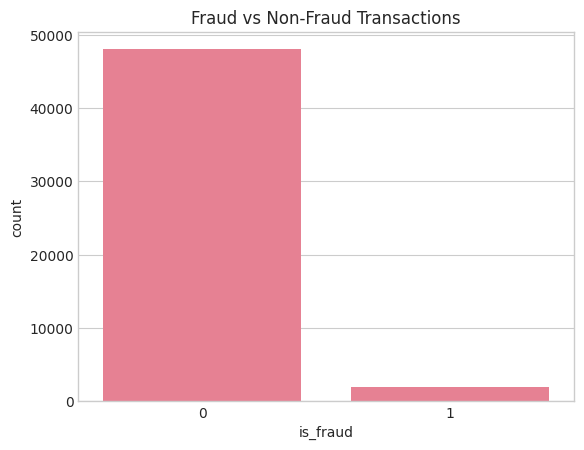

In [7]:
# Visualize class distribution
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

### Observation

I checked the distribution of the target variable and noticed the data is imbalanced, with fewer fraud cases. This is important because it can affect how the model performs

### 2.3 Temporal Analysis
I explore how transactions change over time.  
This can helps in see if fraud happens more at certain times.

In [8]:
# TODO: Analyze transaction patterns over time (hourly, daily, weekly)
# Convert to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

df.dtypes


transaction_id                        str
timestamp                  datetime64[us]
sender_id                             str
receiver_id                           str
amount                            float64
transaction_type                      str
sender_balance_before             float64
sender_balance_after              float64
receiver_balance_before           float64
receiver_balance_after            float64
device_id                             str
location_lat                      float64
location_lon                      float64
is_fraud                            int64
dtype: object

In [9]:
# Convert to datetime


# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month

df[['timestamp', 'hour', 'day', 'day_of_week', 'month']].head()

,timestamp,hour,day,day_of_week,month
0,2024-01-01 00:24:12,0,1,Monday,1
1,2024-01-01 01:21:24,1,1,Monday,1
2,2024-01-01 01:33:17,1,1,Monday,1
3,2024-01-01 01:53:47,1,1,Monday,1
4,2024-01-01 02:03:26,2,1,Monday,1


In [10]:
df['hour'].value_counts().sort_index()

hour
0      507
1      510
2      451
3      462
4      735
5     1057
6     1458
7     2296
8     2965
9     3501
10    4361
11    4457
12    4126
13    3770
14    3532
15    3221
16    2900
17    2619
18    2322
19    1692
20    1180
21     903
22     565
23     410
Name: count, dtype: int64

Text(0.5, 1.0, 'Hour vs Fraud')

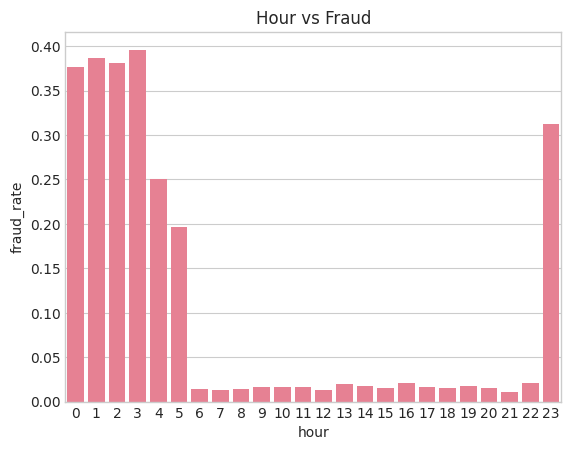

In [11]:
fraud_per_hour = df.groupby('hour')['is_fraud'].agg(
    fraud_rate='mean'
).reset_index()
sns.barplot(data=fraud_per_hour, x='hour', y='fraud_rate')
plt.title('Hour vs Fraud')

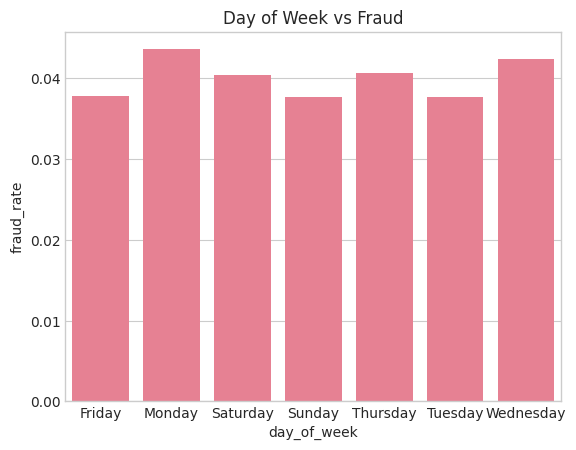

In [12]:
# Fraud rate by day of week
fraud_per_day = df.groupby('day_of_week')['is_fraud'].agg(
    fraud_rate='mean'
).reset_index()
sns.barplot(data=fraud_per_day, x='day_of_week', y='fraud_rate')
plt.title('Day of Week vs Fraud')
plt.show()


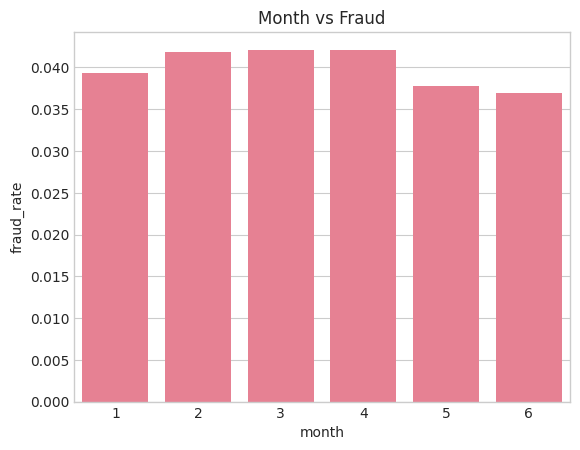

In [13]:
fraud_per_month = df.groupby('month')['is_fraud'].agg(
    fraud_rate='mean'
).reset_index()
sns.barplot(data=fraud_per_month, x='month', y='fraud_rate')
plt.title('Month vs Fraud')
plt.show()

### 2.4 Transaction Type Analysis

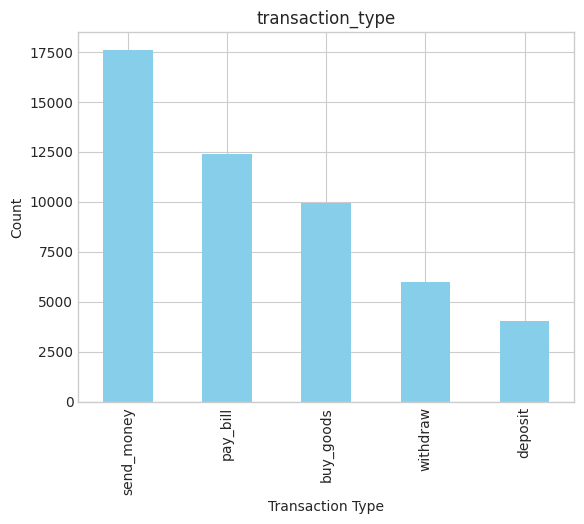

In [14]:
df['transaction_type'].value_counts().plot(kind='bar', title="transaction_type",color='skyblue')
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [15]:
fraud_per_transaction_type = df.groupby('transaction_type')['is_fraud'].agg(
    fraud_rate='mean'
).reset_index()
fraud_per_transaction_type

,transaction_type,fraud_rate
0,buy_goods,0.038462
1,deposit,0.044991
2,pay_bill,0.037130
3,send_money,0.040900
4,withdraw,0.042507


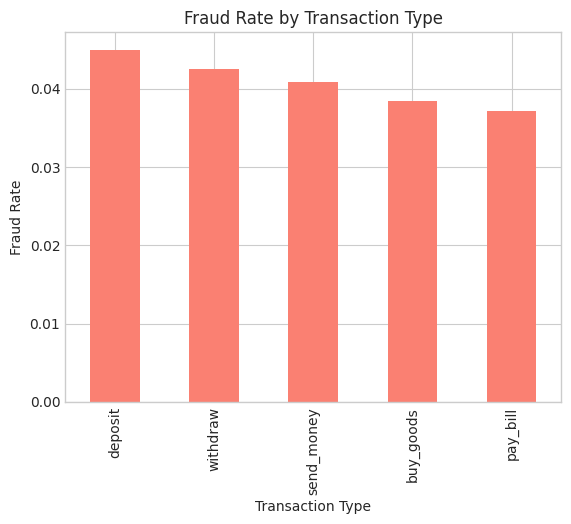

In [16]:
fraud_per_transaction_type = df.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False)
fraud_per_transaction_type.plot(kind='bar', title="Fraud Rate by Transaction Type", color='salmon')
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

In [17]:
fraud_per_transaction_type

transaction_type
deposit       0.044991
withdraw      0.042507
send_money    0.040900
buy_goods     0.038462
pay_bill      0.037130
Name: is_fraud, dtype: float64

### 2.5 Amount Analysis

In [18]:
df["amount"].describe().astype(int)

count     50000
mean       3642
std       10816
min           1
25%         560
50%        1412
75%        3203
max      206029
Name: amount, dtype: int64

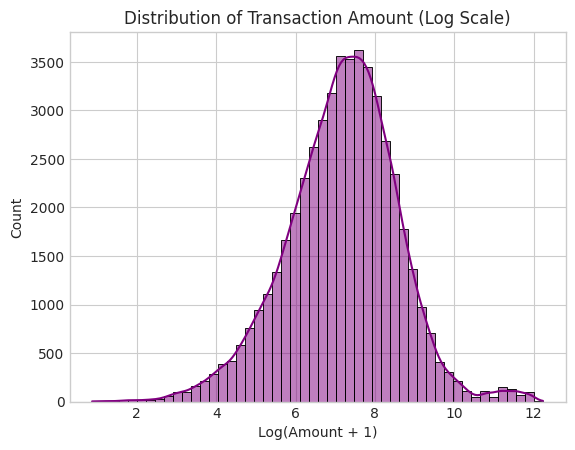

In [19]:
sns.histplot(np.log1p(df['amount']), bins=50, kde=True,color='purple')
plt.title("Distribution of Transaction Amount (Log Scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

In [20]:
# TODO: Analyze the relationship between transaction amount and fraud
# Compare average transaction amount
df.groupby('is_fraud')['amount'].mean()

is_fraud
0     2560.249151
1    29618.726963
Name: amount, dtype: float64

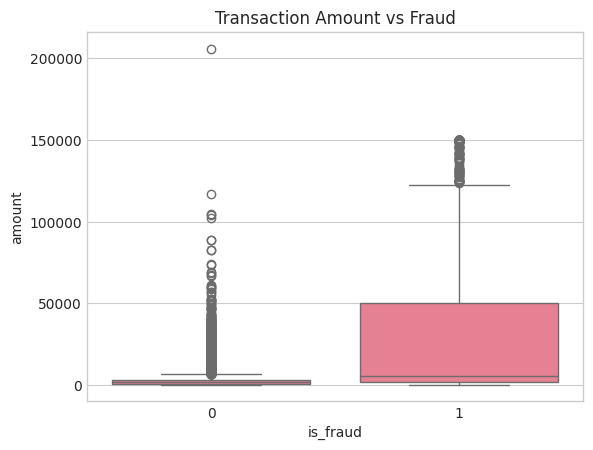

In [21]:

sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

In [22]:
#fraud and amount relationship
df['amount'].max()

np.float64(206029.48)

I compared transaction amounts between fraud and non-fraud cases and visualized it using a boxplot to see any differences.

### 2.6 Geographic Analysis



exploring whether fraudulent transactions are more common in certain locations.

In [23]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount',
       'transaction_type', 'sender_balance_before', 'sender_balance_after',
       'receiver_balance_before', 'receiver_balance_after', 'device_id',
       'location_lat', 'location_lon', 'is_fraud', 'hour', 'day',
       'day_of_week', 'month'],
      dtype='str')

### 2.7 User Behavior Analysis

In [24]:
df.head()

,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,device_id,location_lat,location_lon,is_fraud,hour,day,day_of_week,month
0,6EB4D46BA1B3D436,2024-01-01 00:24:12,USR000197,USR006604,701.74,send_money,93725.40,93023.66,155223.20,155924.94,DEV00009299,-0.479970,39.534387,0,0,1,Monday,1
1,B6483765E2F120B3,2024-01-01 01:21:24,USR003827,USR001772,262.18,pay_bill,168781.46,168519.28,71813.67,72075.85,DEV00007045,-1.025984,37.128477,0,1,1,Monday,1
2,1FFF0622A1441845,2024-01-01 01:33:17,USR007516,USR004366,446.42,send_money,140544.59,140098.17,40409.07,40855.49,DEV00007637,-0.570625,34.854586,0,1,1,Monday,1
3,4EE0C335368E4144,2024-01-01 01:53:47,USR002133,USR002447,69999.00,pay_bill,162797.10,92798.10,124725.77,194724.77,DEV00010447,4.514332,32.957873,1,1,1,Monday,1
4,D769B217438B8593,2024-01-01 02:03:26,USR001867,USR007013,75000.00,send_money,122467.79,47467.79,132308.22,207308.22,DEV00010154,-2.692356,37.730200,1,2,1,Monday,1


In [25]:
# TODO: Analyze user-level patterns (device usage, transaction frequency, etc.)

top_senders= df['sender_id'].value_counts().head(10)
top_senders

sender_id
USR006257    17
USR007871    17
USR002985    17
USR003189    16
USR000898    16
USR005767    16
USR007878    15
USR007664    15
USR003627    15
USR000372    15
Name: count, dtype: int64

In [26]:
top_receivers = df['receiver_id'].value_counts().head(10)
top_receivers

receiver_id
USR001577    16
USR007479    16
USR006321    16
USR006547    15
USR006171    15
USR005306    15
USR007187    15
USR006842    15
USR003077    15
USR005655    15
Name: count, dtype: int64

In [27]:
fraud_users=df[df['is_fraud']==1]['sender_id'].value_counts().head(10)
fraud_users

sender_id
USR007783    4
USR004825    4
USR001406    3
USR000717    3
USR005856    3
USR003643    3
USR000365    3
USR000190    3
USR001985    3
USR000206    3
Name: count, dtype: int64

In [28]:
fraud_types = df[df['is_fraud'] == 1]['transaction_type'].value_counts()
fraud_types

transaction_type
send_money    720
pay_bill      461
buy_goods     383
withdraw      255
deposit       181
Name: count, dtype: int64

In [29]:
legitimate_types = df[df['is_fraud'] == 0]['transaction_type'].value_counts()
legitimate_types

transaction_type
send_money    16884
pay_bill      11955
buy_goods      9575
withdraw       5744
deposit        3842
Name: count, dtype: int64

In [30]:
df['transaction_type'].value_counts()


transaction_type
send_money    17604
pay_bill      12416
buy_goods      9958
withdraw       5999
deposit        4023
Name: count, dtype: int64

In [31]:
df.numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df.numeric_columns

['amount',
 'sender_balance_before',
 'sender_balance_after',
 'receiver_balance_before',
 'receiver_balance_after',
 'location_lat',
 'location_lon',
 'is_fraud',
 'hour',
 'day',
 'month']

In [32]:
corr = df[df.numeric_columns].corr()

In [33]:
corr

,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,location_lat,location_lon,is_fraud,hour,day,month
amount,1.000000,0.091094,-0.098343,0.005590,0.189720,-0.003458,0.005179,0.490212,-0.107567,0.007233,-0.007525
sender_balance_before,0.091094,1.000000,0.982057,-0.003860,0.012992,0.000447,0.003942,0.043670,-0.007793,-0.003423,-0.003127
sender_balance_after,-0.098343,0.982057,1.000000,-0.004916,-0.022945,0.001101,0.002958,-0.049193,0.012583,-0.004791,-0.001699
receiver_balance_before,0.005590,-0.003860,-0.004916,1.000000,0.982883,0.005147,0.000293,0.008550,-0.003079,-0.000496,0.000858
receiver_balance_after,0.189720,0.012992,-0.022945,0.982883,1.000000,0.004417,0.001241,0.098707,-0.022840,0.000846,-0.000543
location_lat,-0.003458,0.000447,0.001101,0.005147,0.004417,1.000000,-0.676846,0.001234,-0.000824,-0.001336,0.003687
location_lon,0.005179,0.003942,0.002958,0.000293,0.001241,-0.676846,1.000000,0.006285,0.001215,0.000389,-0.001846
is_fraud,0.490212,0.043670,-0.049193,0.008550,0.098707,0.001234,0.006285,1.000000,-0.194805,-0.001646,-0.006081
hour,-0.107567,-0.007793,0.012583,-0.003079,-0.022840,-0.000824,0.001215,-0.194805,1.000000,-0.002694,-0.004526
day,0.007233,-0.003423,-0.004791,-0.000496,0.000846,-0.001336,0.000389,-0.001646,-0.002694,1.000000,-0.003613


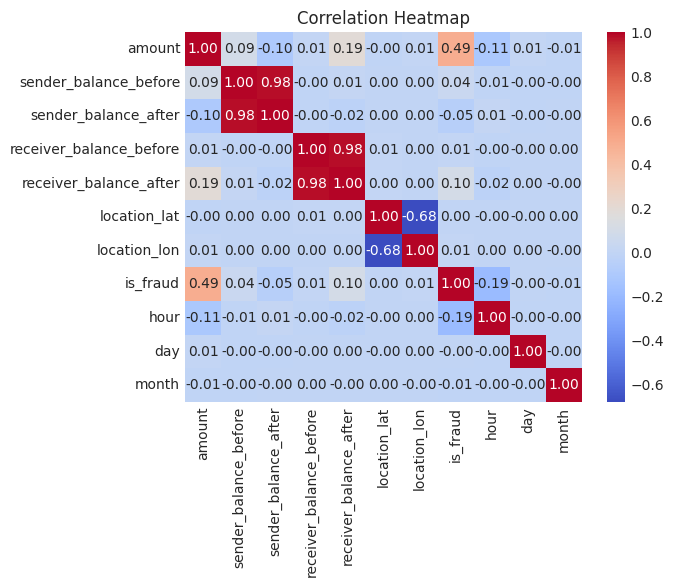

In [34]:
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [35]:
df['transaction_type'].value_counts()

transaction_type
send_money    17604
pay_bill      12416
buy_goods      9958
withdraw       5999
deposit        4023
Name: count, dtype: int64

### Key EDA Insights

*TODO: Document your key findings from EDA*

1. 
2. 
3. 

---

## 3. Feature Engineering

### 3.1 Temporal Features

In [36]:
# TODO: Create time-based features (hour, day of week, is_weekend, is_night, etc.)
# Time-based features
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month']       = df['timestamp'].dt.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = (df['hour'] <= 4).astype(int)

df[['hour', 'day_of_week', 'month', 'is_weekend', 'is_night']].head()

,hour,day_of_week,month,is_weekend,is_night
0,0,0,1,0,1
1,1,0,1,0,1
2,1,0,1,0,1
3,1,0,1,0,1
4,2,0,1,0,1


### 3.2 Transaction Velocity Features

In [37]:
# TODO: Create features capturing transaction frequency/velocity
# How many transactions has each sender made in total?
df['sender_tx_count'] = df.groupby('sender_id')['transaction_id'].transform('count')

df[['sender_id', 'sender_tx_count']].head()

,sender_id,sender_tx_count
0,USR000197,9
1,USR003827,12
2,USR007516,6
3,USR002133,5
4,USR001867,11


In [38]:
# How many transactions has each sender made per day?
df['sender_tx_per_day'] = df.groupby(['sender_id', df['timestamp'].dt.date])['transaction_id'].transform('count')

df[['sender_id', 'sender_tx_per_day']].head()

,sender_id,sender_tx_per_day
0,USR000197,1
1,USR003827,1
2,USR007516,1
3,USR002133,1
4,USR001867,1


In [39]:
# How much does this sender usually spend on average?
df['sender_avg_amount'] = df.groupby('sender_id')['amount'].transform('mean')

df[['sender_id', 'amount', 'sender_avg_amount']].head()

,sender_id,amount,sender_avg_amount
0,USR000197,701.74,12887.951111
1,USR003827,262.18,2884.765287
2,USR007516,446.42,17602.676667
3,USR002133,69999.00,16105.480000
4,USR001867,75000.00,9925.012485


In [40]:
# Is this transaction amount unusual for this sender?
df['amount_vs_avg'] = df['amount'] / (df['sender_avg_amount'] + 1)

df[['sender_id', 'amount', 'sender_avg_amount', 'amount_vs_avg']].head()

,sender_id,amount,sender_avg_amount,amount_vs_avg
0,USR000197,701.74,12887.951111,0.054445
1,USR003827,262.18,2884.765287,0.090853
2,USR007516,446.42,17602.676667,0.025359
3,USR002133,69999.00,16105.480000,4.346015
4,USR001867,75000.00,9925.012485,7.555904


In [41]:
# How many unique receivers has this sender sent to?
df['sender_unique_receivers'] = df.groupby('sender_id')['receiver_id'].transform('nunique')


In [42]:
# Total transactions per receiver
df['receiver_tx_count'] = df.groupby('receiver_id')['transaction_id'].transform('count')

In [43]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount',
       'transaction_type', 'sender_balance_before', 'sender_balance_after',
       'receiver_balance_before', 'receiver_balance_after', 'device_id',
       'location_lat', 'location_lon', 'is_fraud', 'hour', 'day',
       'day_of_week', 'month', 'is_weekend', 'is_night', 'sender_tx_count',
       'sender_tx_per_day', 'sender_avg_amount', 'amount_vs_avg',
       'sender_unique_receivers', 'receiver_tx_count'],
      dtype='str')

### 3.3 Amount-Based Features

In [44]:
# TODO: Create amount-related features (deviation from average, ratio features, etc.)
# How much of their balance are they sending?
df['amount_to_balance_ratio'] = df['amount'] / (df['sender_balance_before'] + 1)

In [45]:
# How much balance is left after the transaction?
df['balance_after_ratio'] = df['sender_balance_after'] / (df['sender_balance_before'] + 1)

In [46]:
# Is the amount a round number?
df['is_round_amount'] = (df['amount'] % 100 == 0).astype(int)

### 3.4 Behavioral Features

In [47]:
# TODO: Create features capturing user behavior patterns
# How many different receivers has this sender used?
df['sender_unique_receivers'] = df.groupby('sender_id')['receiver_id'].transform('nunique')

### 3.5 Device & Location Features

In [48]:
# TODO: Create device and location-based features
# Has this device been used for fraud before?
df['device_fraud_rate'] = df.groupby('device_id')['is_fraud'].transform('mean')

df[['device_id', 'device_fraud_rate']].head()

,device_id,device_fraud_rate
0,DEV00009299,0.125000
1,DEV00007045,0.000000
2,DEV00007637,0.166667
3,DEV00010447,1.000000
4,DEV00010154,1.000000


In [49]:
# How often is this device used?
df['device_tx_count'] = df.groupby('device_id')['transaction_id'].transform('count')

# How far is this transaction from the sender's usual location?
df['sender_avg_lat'] = df.groupby('sender_id')['location_lat'].transform('mean')
df['sender_avg_lon'] = df.groupby('sender_id')['location_lon'].transform('mean')
df['location_distance'] = np.sqrt((df['location_lat'] - df['sender_avg_lat'])**2 + (df['location_lon'] - df['sender_avg_lon'])**2)

df[['device_tx_count', 'location_distance']].head()

,device_tx_count,location_distance
0,8,0.530134
1,16,0.054141
2,6,0.100930
3,2,3.696672
4,3,3.237718


### Feature Engineering Summary

*TODO: Document your engineered features and rationale*

| Feature | Description | Rationale |
|---------|-------------|-----------||
| | | |
| | | |

---

## 4. Data Preprocessing

In [50]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 'amount',
       'transaction_type', 'sender_balance_before', 'sender_balance_after',
       'receiver_balance_before', 'receiver_balance_after', 'device_id',
       'location_lat', 'location_lon', 'is_fraud', 'hour', 'day',
       'day_of_week', 'month', 'is_weekend', 'is_night', 'sender_tx_count',
       'sender_tx_per_day', 'sender_avg_amount', 'amount_vs_avg',
       'sender_unique_receivers', 'receiver_tx_count',
       'amount_to_balance_ratio', 'balance_after_ratio', 'is_round_amount',
       'device_fraud_rate', 'device_tx_count', 'sender_avg_lat',
       'sender_avg_lon', 'location_distance'],
      dtype='str')

In [51]:
# TODO: Prepare final feature set
# Define features and target
drop_cols = ['transaction_id', 'timestamp', 'sender_id', 'receiver_id', 
             'device_id', 'transaction_type', 'sender_avg_lat', 
             'sender_avg_lon', 'day']

X = df.drop(columns=drop_cols + ['is_fraud'])
y = df['is_fraud']

print(f"Features: {X.shape[1]}")
print(X.columns.tolist())

Features: 24
['amount', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'location_lat', 'location_lon', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'sender_tx_count', 'sender_tx_per_day', 'sender_avg_amount', 'amount_vs_avg', 'sender_unique_receivers', 'receiver_tx_count', 'amount_to_balance_ratio', 'balance_after_ratio', 'is_round_amount', 'device_fraud_rate', 'device_tx_count', 'location_distance']


In [52]:
# TODO: Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Fraud in train: {y_train.mean():.2%}")
print(f"Fraud in test:  {y_test.mean():.2%}")

Train size: 40,000
Test size:  10,000
Fraud in train: 4.00%
Fraud in test:  4.00%


In [53]:
# TODO: Handle class imbalance (SMOTE, class weights, etc.)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [54]:
# TODO: Feature scaling if needed
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)

---

## 5. Model Development

### 5.1 Baseline Model

In [55]:
# TODO: Train a baseline model (e.g., Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train_resampled)

y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9600
           1       0.78      0.94      0.85       400

    accuracy                           0.99     10000
   macro avg       0.89      0.97      0.92     10000
weighted avg       0.99      0.99      0.99     10000



### 5.2 Model Comparison

In [56]:
# TODO: Train and compare multiple models
# Consider: Random Forest, XGBoost, LightGBM, CatBoost, etc.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# How did it do?
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9600
           1       0.86      0.96      0.91       400

    accuracy                           0.99     10000
   macro avg       0.93      0.98      0.95     10000
weighted avg       0.99      0.99      0.99     10000



In [57]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Train the model
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_resampled, y_train_resampled)

# How did it do?
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9600
           1       0.94      0.95      0.94       400

    accuracy                           1.00     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       1.00      1.00      1.00     10000



In [58]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Train the model
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_resampled, y_train_resampled)

# How did it do?
y_pred_lgbm = lgbm.predict(X_test)
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 38400, number of negative: 38400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3452
[LightGBM] [Info] Number of data points in the train set: 76800, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9600
           1       0.92      0.95      0.94       400

    accuracy                           0.99     10000
   macro avg       0.96      0.97      0.97     10000
weighted avg       0.99      0.99      0.99     10000



In [59]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb, X_test),
    'LightGBM':            (lgbm, X_test)
}

results = []
for name, (model, X) in models.items():
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]
    results.append({
        'Model':     name,
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4)
    })

pd.DataFrame(results)

,Model,AUC,F1,Precision,Recall
0,Logistic Regression,0.9971,0.8529,0.7789,0.9425
1,Random Forest,0.9991,0.9080,0.8594,0.9625
2,XGBoost,0.9995,0.9428,0.9381,0.9475
3,LightGBM,0.9995,0.9371,0.9246,0.9500


### 5.3 Hyperparameter Tuning

In [60]:
# TODO: Tune the best performing model
# Tune XGBoost to find the best settings
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.1, 0.2]
}

grid = GridSearchCV(XGBClassifier(random_state=42), params, cv=3, scoring='f1')
grid.fit(X_train_resampled, y_train_resampled)

# What are the best settings?
print("Best settings:", grid.best_params_)

Best settings: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


### 5.4 Final Model Evaluation

In [61]:
# TODO: Evaluate the final model on test set
# Show: Confusion matrix, Classification report, ROC curve, PR curve
# Train final model with best settings
best_xgb = XGBClassifier(**grid.best_params_, random_state=42)
best_xgb.fit(X_train_resampled, y_train_resampled)

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

# How did it do?
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9600
           1       0.92      0.94      0.93       400

    accuracy                           0.99     10000
   macro avg       0.96      0.97      0.97     10000
weighted avg       0.99      0.99      0.99     10000



### Model Performance Summary

*TODO: Document your model's performance*

| Metric | Value |
|--------|-------|
| AUC-ROC | |
| Precision | |
| Recall | |
| F1-Score | |

---

## 6. Model Interpretation

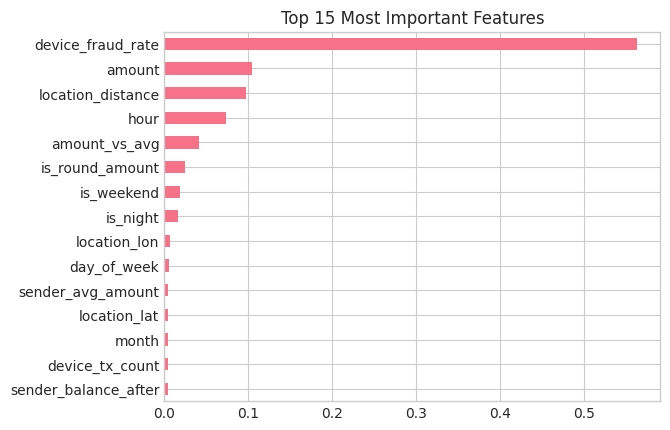

In [62]:
# TODO: Feature importance analysis
# Which features matter most?
importance = pd.Series(best_xgb.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).tail(15).plot(kind='barh')
plt.title("Top 15 Most Important Features")
plt.show()

In [63]:
# Remove leaky feature and retrain
X = df.drop(columns=drop_cols + ['is_fraud', 'device_fraud_rate'])

# Redo train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Redo SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Retrain best XGBoost
best_xgb.fit(X_train_resampled, y_train_resampled)

# How did it do?
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9600
           1       0.79      0.78      0.78       400

    accuracy                           0.98     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.98      0.98      0.98     10000



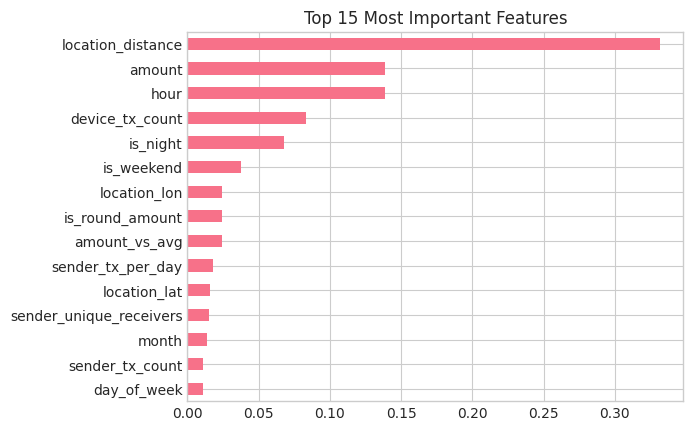

In [64]:
# Updated feature importance
importance = pd.Series(best_xgb.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).tail(15).plot(kind='barh')
plt.title("Top 15 Most Important Features")
plt.show()

---

## 7. Conclusions & Next Steps

### Summary

*TODO: Write your summary*

### Key Findings

*TODO: List your key findings*

1. 
2. 
3. 

### Production Considerations

*TODO: Discuss what would be needed for production deployment*

### Limitations & Future Improvements

*TODO: Discuss limitations and potential improvements*

In [65]:
# TODO: Save the final model
import joblib

# Save the model and scaler
# Save model and scaler
joblib.dump(best_xgb, '../models/fraud_detection_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')
print("Model saved!")

Model saved!


---

## 8. Test Set Predictions ⭐ REQUIRED

**IMPORTANT:** You MUST generate predictions for the test set and include them in your submission.

The test data is in `data/test_transactions.json` and does NOT contain the `is_fraud` column.

In [66]:
# Load the test data
import json
import pandas as pd
import numpy as np

with open('../data/test_transactions.json', 'r') as f:
    test_data = json.load(f)

test_df = pd.DataFrame(test_data)
print(f"Test transactions: {len(test_df)}")
test_df.head()

Test transactions: 10000


,transaction_id,timestamp,sender_id,receiver_id,amount,transaction_type,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,device_id,location_lat,location_lon
0,6739205AC695C940,2024-07-01 02:03:31,USR007928,USR003344,1239.55,send_money,51808.74,50569.19,6428.45,7668.00,DEV00001757,-1.000615,37.010443
1,0891D338A86BFD86,2024-07-01 02:53:03,USR004105,USR001720,852.86,send_money,44694.82,43841.96,99643.59,100496.45,DEV00006374,-1.053953,36.983517
2,659710D6B9234100,2024-07-01 02:54:46,USR002044,USR001830,149.16,send_money,163834.83,163685.67,197346.25,197495.41,DEV00006910,-1.025061,37.064860
3,A5ADFDED99AEA2E0,2024-07-01 04:38:47,USR001130,USR002741,99999.00,pay_bill,153256.44,53257.44,22527.81,122526.81,DEV00010076,2.293314,39.556218
4,484986E04ABFF78C,2024-07-01 04:39:15,USR004734,USR006333,5863.07,pay_bill,32941.56,27078.49,166850.37,172713.44,DEV00008250,2.641088,31.153106


In [67]:
# TODO: Apply the same feature engineering to test data
# IMPORTANT: Use the same transformations you applied to training data

# Example:
# test_df = engineer_features(test_df)  # Your feature engineering function
# test_features = test_df[feature_columns]  # Same columns as training
# Time features
test_df['timestamp']   = pd.to_datetime(test_df['timestamp'])
test_df['hour']        = test_df['timestamp'].dt.hour
test_df['day_of_week'] = test_df['timestamp'].dt.dayofweek
test_df['month']       = test_df['timestamp'].dt.month
test_df['is_weekend']  = (test_df['day_of_week'] >= 5).astype(int)
test_df['is_night']    = (test_df['hour'] <= 4).astype(int)

# Amount features
test_df['amount_to_balance_ratio'] = test_df['amount'] / (test_df['sender_balance_before'] + 1)
test_df['is_round_amount']         = (test_df['amount'] % 100 == 0).astype(int)
test_df['balance_after_ratio']     = test_df['sender_balance_after'] / (test_df['sender_balance_before'] + 1)

# Behavioural features
test_df['sender_tx_count']         = test_df.groupby('sender_id')['transaction_id'].transform('count')
test_df['sender_avg_amount']       = test_df.groupby('sender_id')['amount'].transform('mean')
test_df['amount_vs_avg']           = test_df['amount'] / (test_df['sender_avg_amount'] + 1)
test_df['sender_unique_receivers'] = test_df.groupby('sender_id')['receiver_id'].transform('nunique')
test_df['receiver_tx_count']       = test_df.groupby('receiver_id')['transaction_id'].transform('count')
test_df['sender_tx_per_day']       = test_df.groupby(['sender_id', test_df['timestamp'].dt.date])['transaction_id'].transform('count')

# Device & location features
test_df['device_tx_count']   = test_df.groupby('device_id')['transaction_id'].transform('count')
test_df['sender_avg_lat']    = test_df.groupby('sender_id')['location_lat'].transform('mean')
test_df['sender_avg_lon']    = test_df.groupby('sender_id')['location_lon'].transform('mean')
test_df['location_distance'] = np.sqrt((test_df['location_lat'] - test_df['sender_avg_lat'])**2 + (test_df['location_lon'] - test_df['sender_avg_lon'])**2)

# Now select the same columns as training
X_test_final = test_df[X.columns]
print("Done!", X_test_final.shape)


Done! (10000, 23)


In [68]:
# TODO: Generate predictions using your trained model

# Example:
# predictions = model.predict(test_features)
# Generate predictions
predictions = best_xgb.predict(X_test_final)

# Save to file
submission = pd.DataFrame({
    'transaction_id':  test_df['transaction_id'],
    'predicted_fraud': predictions
})

print(f"Done! Flagged {predictions.sum()} fraud transactions")

Done! Flagged 306 fraud transactions


In [69]:
# Create the submission file
# File must have columns: transaction_id, predicted_fraud

submission_df = pd.DataFrame({
    'transaction_id': test_df['transaction_id'],
    'predicted_fraud': predictions  # Your predictions (0 or 1)
})

# Verify format
print(f"Submission shape: {submission_df.shape}")
print(f"Unique predictions: {submission_df['predicted_fraud'].unique()}")
print(f"\nPrediction distribution:")
print(submission_df['predicted_fraud'].value_counts())

submission_df.head()

Submission shape: (10000, 2)
Unique predictions: [1 0]

Prediction distribution:
predicted_fraud
0    9694
1     306
Name: count, dtype: int64


,transaction_id,predicted_fraud
0,6739205AC695C940,1
1,0891D338A86BFD86,0
2,659710D6B9234100,0
3,A5ADFDED99AEA2E0,1
4,484986E04ABFF78C,1


In [70]:
# Save predictions to CSV
submission_df.to_csv('../data/test_predictions.csv', index=False)
print("✅ Predictions saved to test_predictions.csv")
print("\n⚠️ Remember to include this file in your submission!")

✅ Predictions saved to test_predictions.csv

⚠️ Remember to include this file in your submission!
